🚀 [1/7] Naive Bayes 訓練開始...
✅ Accuracy: 0.6339
                  precision    recall  f1-score   support

      feel_angry       0.61      0.60      0.61       635
     feel_boring       0.62      0.48      0.54       285
 feel_depressing       0.61      0.57      0.59       320
      feel_happy       0.60      0.54      0.57       978
feel_informative       0.67      0.78      0.72      1979
        feel_odd       0.49      0.40      0.44       295
       feel_warm       0.73      0.46      0.56       181
    feel_worried       0.75      0.27      0.40        55

        accuracy                           0.63      4728
       macro avg       0.63      0.51      0.55      4728
    weighted avg       0.63      0.63      0.63      4728



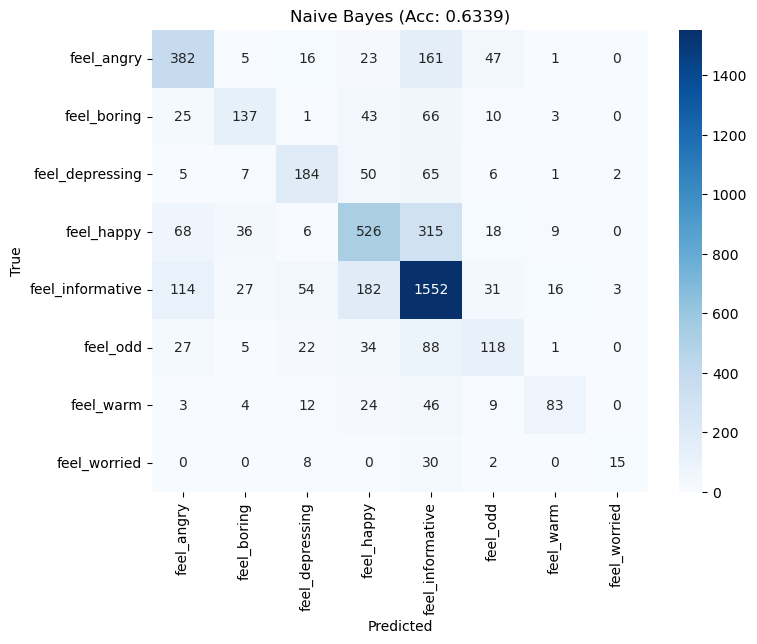

In [1]:
# 1_Naive_Bayes.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

if __name__ == '__main__':
    print("🚀 [1/7] Naive Bayes 訓練開始...")
    start_time = time.time()

    # 1. 讀取處理好的資料
    try:
        df = pd.read_csv('Processed_Data.csv')
        df['text_segmented'] = df['text_segmented'].fillna('')
    except:
        print("❌ 找不到 Processed_Data.csv")
        exit()

    X_text = df['text_segmented'].values
    y_raw = df['Column1'].values

    # 2. 特徵工程
    vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True, dtype=np.float32)
    X_tfidf = vectorizer.fit_transform(X_text)
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    
    # 3. 切分
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(X_tfidf))
    X_train, X_test = X_tfidf[train_idx], X_tfidf[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # 4. 訓練
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # 5. 評估
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    # 6. 繪圖
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Naive Bayes (Acc: {acc:.4f})')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()